# Numerical Quadrature Integration Library: Getting Started Guide

Welcome to the quick-start guide for the `sciforge.integrate.quadrature` suite. This notebook demonstrates how to utilise both classical and advanced numerical integration techniques.

### What is covered:
1. **Classical Solvers**: Fixed-grid calculations using Trapezoidal and Simpson's 1/3 rules.
2. **Parallel Boundaries**: Handling vectorised integration limits concurrently.
3. **High-Performance Methods**: Gauss-Legendre quadrature and Clenshaw-Curtis solvers.
4. **Handling Singularities**: Resolving vertical slopes using Adaptive Simpson's and Tanh-Sinh engines.
5. **Infinite Fields**: Solving improper integrals on unbounded ranges.

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Import our core library code
from sciforge.integrate.quadrature import QuadratureIntegrator

# Configure clean plot aesthetics
%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11

print("Environment successfully configured. Ready to integrate!")

Environment successfully configured. Ready to integrate!


## 1. Baseline Usage - Classical Fixed-Grid Solvers

Let's look at a straightforward problem: integrating the harmonic wave function:
$$f(x) = \sin(x)$$

from $0$ to $\pi$. The exact analytical result is **$2.0$**.

We will evaluate this using the **Trapezoidal** and **Simpson's 1/3** rules while monitoring their internal performance metrics.

In [8]:
# 1. Define your vector-safe mathematical function target
target_function = lambda x: np.sin(x)  # noqa: E731

# 2. Instantiate your single integration suite engine
integrator = QuadratureIntegrator(target_function)

a, b = 0.0, np.pi
panels = 20  # Total grid panels

# 3. Run calculations and inspect results alongside performance metrics
val_trap = integrator.trapezoidal(a, b, n=panels)
metrics_trap = integrator.metrics.copy()

val_simp = integrator.simpsons(a, b, n=panels)
metrics_simp = integrator.metrics.copy()

print("Exact Analytical Answer: 2.0\n")
print(f"[Trapezoidal] Result: {val_trap:.8f} | Error: {abs(2.0 - val_trap):.2e}")
print(f"Telemetry Logs: {metrics_trap}\n")
print(f"[Simpson's 1/3] Result: {val_simp:.8f} | Error: {abs(2.0 - val_simp):.2e}")
print(f"Telemetry Logs: {metrics_simp}")

Exact Analytical Answer: 2.0

[Trapezoidal] Result: 1.99588597 | Error: 4.11e-03
Telemetry Logs: {'function_evaluations': 21, 'execution_time_seconds': 0.0003046549991267966, 'max_recursion_depth': 0, 'estimated_error': 0.0}

[Simpson's 1/3] Result: 2.00000678 | Error: 6.78e-06
Telemetry Logs: {'function_evaluations': 21, 'execution_time_seconds': 0.00018051100050797686, 'max_recursion_depth': 0, 'estimated_error': 0.0}


### Visualising Grid-Panel Slicing
Let's see a visual representation of how the Trapezoidal rule builds its approximation slices across the domain interval.

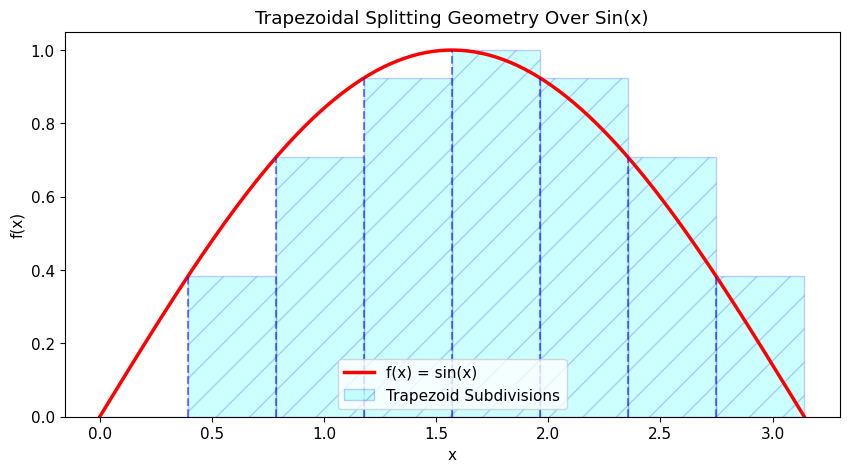

In [9]:
x_plot = np.linspace(a, b, 200)
plt.plot(x_plot, target_function(x_plot), "r-", linewidth=2.5, label="f(x) = sin(x)")

# Draw 8 illustrative sample intervals
x_grid = np.linspace(a, b, 9)
y_grid = target_function(x_grid)

plt.bar(
    x_grid[:-1],
    y_grid[:-1],
    width=np.diff(x_grid),
    align="edge",
    alpha=0.2,
    edgecolor="blue",
    color="cyan",
    hatch="/",
    label="Trapezoid Subdivisions",
)
plt.vlines(x_grid, 0, y_grid, colors="blue", linestyles="dashed", alpha=0.5)

plt.title("Trapezoidal Splitting Geometry Over Sin(x)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend(loc="lower center")
plt.show()

## 2️. Speed and Scalability - Vectorised Parallel Boundaries

One of the major features of this library is its ability to handle **vectorised boundary inputs**. This lets you calculate multiple integration domains simultaneously in parallel.

Let's calculate the area under $f(x) = x^3$ from a shared lower limit of $0.0$, running across **three separate upper limit conditions** ($1.0, 2.0, 3.0$) concurrently in a single operation.

In [10]:
vector_integrator = QuadratureIntegrator(lambda x: x**3)

lower_bound = 0.0
upper_bounds_vector = np.array([1.0, 2.0, 3.0])

# The mathematical results for x^3 are 0.25 * b^4 -> [0.25, 4.0, 20.25]
vector_results = vector_integrator.gauss_legendre(
    lower_bound, upper_bounds_vector, deg=8
)

print(f"Vector Bound Arrays Passed: {upper_bounds_vector}")
print(f"Calculated Parallel Outputs: {vector_results}")
print(f"Total Audited Evaluations: {vector_integrator.metrics['function_evaluations']}")

Vector Bound Arrays Passed: [1. 2. 3.]
Calculated Parallel Outputs: [ 0.25  4.   20.25]
Total Audited Evaluations: 24


## 3️. High-Performance Advanced Solvers

When you need maximum precision with minimal function evaluations, fixed-grid methods become less efficient. This library provides two advanced mathematical techniques:
- **Gauss-Legendre Quadrature**: Calculates optimal non-uniform mathematical nodes via matrix transformations.
- **Clenshaw-Curtis Quadrature**: Leverages Chebyshev nodes to optimize smooth tracking approximations.

Let's integrate an exponential growth curve $f(x) = e^x$ from $0$ to $1$. (Analytical Value = $e - 1 \approx 1.71828183$).

In [11]:
exp_integrator = QuadratureIntegrator(lambda x: np.exp(x))
exact_exp = np.e - 1.0

# Evaluate both using only 6 node points
nodes_count = 6
val_gl = exp_integrator.gauss_legendre(0.0, 1.0, deg=nodes_count)
val_cc = exp_integrator.clenshaw_curtis(0.0, 1.0, n=nodes_count)

print(f"Reference Target Value: {exact_exp:.10f}\n")
print(
    f"[Gauss-Legendre] ({nodes_count} Nodes) Result: {val_gl:.10f} | Error: {abs(exact_exp - val_gl):.2e}"
)
print(
    f"[Clenshaw-Curtis] ({nodes_count} Nodes) Result: {val_cc:.10f} | Error: {abs(exact_exp - val_cc):.2e}"
)

Reference Target Value: 1.7182818285

[Gauss-Legendre] (6 Nodes) Result: 1.7182818285 | Error: 0.00e+00
[Clenshaw-Curtis] (6 Nodes) Result: 1.7182818284 | Error: 6.41e-11


## 4️. Dynamic Refinement and Handling Singularities

Functions often feature localised spikes or vertical endpoints tangents where fixed nodes can miss critical areas or trigger division-by-zero crashes.

### Case A: Adaptive Grid Allocation
Let's look at an oscillatory function: $f(x) = \sin(1/x)$. The curve accelerates dramatically near zero. 

**Adaptive Simpson's** handles this by automatically sub-dividing the coordinate space only where the function changes rapidly, avoiding unnecessary calculations in flatter regions.

In [12]:
oscillatory_func = lambda x: np.sin(1.0 / (x + 1e-4))  # noqa: E731
adaptive_engine = QuadratureIntegrator(oscillatory_func)

val_adaptive = adaptive_engine.adaptive_simpsons(0.0, 2.0, tol=1e-5)
print(f"Adaptive Simpson Result: {val_adaptive:.6f}")
print(
    f"Deep Max Recursion Depth Reached: {adaptive_engine.metrics['max_recursion_depth']}"
)
print(
    f"Total Function Evaluations:       {adaptive_engine.metrics['function_evaluations']}"
)

Adaptive Simpson Result: 1.136681
Deep Max Recursion Depth Reached: 29
Total Function Evaluations:       67249


### Case B: Handling Endpoint Singularities
Let's consider an explicit vertical tangent: 
$$f(x) = \frac{1}{\sqrt{x}}$$

Integrating from $0$ to $1$ yields exactly **$2.0$**. However, evaluating absolute $x=0$ throws a fatal division-by-zero exception.

**Tanh-Sinh Quadrature** solves this by evaluating points on an open interval. It maps nodes away from the endpoints while transforming the grid step size exponentially to capture the asymptotic area cleanly.

In [13]:
singularity_func = lambda x: 1.0 / np.sqrt(x)  # noqa: E731
singularity_engine = QuadratureIntegrator(singularity_func)

try:
    # Standard Simpson's will hit the 0 point and crash
    singularity_engine.simpsons(0.0, 1.0, n=20)
except ValueError as safe_err:
    print(f"Standard Solver Intercepted Expected Error: '{safe_err}'")

# Tanh-Sinh approaches the boundary exponentially without touching it
val_ts = singularity_engine.tanh_sinh(0.0, 1.0, tol=1e-6)
print(
    f"\nTanh-Sinh Quadrature Recovery Result: {val_ts:.6f} (Error: {abs(2.0 - val_ts):.2e})"
)

Standard Solver Intercepted Expected Error: 'Target function returned NaN or Inf. Structural singularity detected.'

Tanh-Sinh Quadrature Recovery Result: 2.000000 (Error: 1.09e-08)


/tmp/ipykernel_27849/3344680363.py:1: RuntimeWarning: divide by zero encountered in divide
  singularity_func = lambda x: 1.0 / np.sqrt(x)  # noqa: E731


## 5️. Unbounded Coordinates - Improper Infinite Integrals

Physical simulations frequently require integrating out to infinity. This suite provides an automated variable transformation layer (`integrate_infinite`) to handle these cases.

Let's solve the standard **Gaussian distribution bell curve** across an infinite domain:
$$\\int_{-\infty}^{\infty} e^{-x^2} dx = \sqrt{\pi} \approx 1.77245385$$

In [14]:
gaussian_bell = lambda x: np.exp(-(x**2))  # noqa: E731
infinite_engine = QuadratureIntegrator(gaussian_bell)
exact_sqrt_pi = np.sqrt(np.pi)

res_unbounded = infinite_engine.integrate_infinite(
    -np.inf, np.inf, method="gauss_legendre", deg=64
)

print(f"Theoretical Expected Limit (Sqrt(Pi)): {exact_sqrt_pi:.8f}")
print(f"Infinite Transformation Output Value: {res_unbounded:.8f}")
print(f"Absolute Variance Delta: {abs(exact_sqrt_pi - res_unbounded):.2e}")

Theoretical Expected Limit (Sqrt(Pi)): 1.77245385
Infinite Transformation Output Value: 1.77245385
Absolute Variance Delta: 8.54e-11


## Summary - Choosing the Right Tool

| Objective Target Scenario | Optimal Core Library Method | Key Advantage |
| :--- | :--- | :--- |
| **Smooth Polynomial Fields** | `.gauss_legendre(..., deg=N)` | Highest precision with minimal node counts. |
| **Parallel Iteration Sweeps** | Any Classical / Advanced Method | Pass array boundaries (`np.ndarray`) for batch processing. |
| **Localised Spikes or Waves** | `.adaptive_simpsons(..., tol)` | Spatially targets regions with rapid variations. |
| **Asymptotic Boundary Slopes** | `.tanh_sinh(...)` | Safely bypasses division-by-zero crashes. |
| **Unbounded Infinity Fields** | `.integrate_infinite(-np.inf, np.inf)` | Translates infinite coordinates into finite bounds. |